# ENSU 2025 Perceived Insecurity Analysis

This notebook presents the final analytical pipeline for the ENSU 2025 project, including:

- quarterly data integration
- variable selection and preprocessing
- feature engineering
- descriptive and relational analysis
- clustering-based segmentation
- export of final artifacts for the report and dashboard

In [23]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path("..").resolve()))

from src.load_data import load_all_quarters, concat_quarters, get_common_columns
from src.preprocess import (
    clean_analysis_dataset,
    PERCEPTION_COLUMNS,
)
from src.features import categorize_insecurity
from src.visualize import (
    plot_top_cities,
    plot_quarter_trend,
    plot_sex_comparison,
)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
TABLES_DIR = Path("../outputs/tables")
FIGURES_DIR = Path("../outputs/figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Data loading

The four quarterly ENSU 2025 ZIP files are loaded directly from the raw folder.  
Only the CB module is used, as it contains the variables relevant to insecurity perception.

In [24]:
file_map = {
    "2025_Q1": "ensu_2025_q1.zip",
    "2025_Q2": "ensu_2025_q2.zip",
    "2025_Q3": "ensu_2025_q3.zip",
    "2025_Q4": "ensu_2025_q4.zip",
}

dfs = load_all_quarters(RAW_DIR, file_map)

for quarter, df in dfs.items():
    print(quarter, df.shape)

2025_Q1 (23591, 147)
2025_Q2 (23717, 151)
2025_Q3 (23642, 244)
2025_Q4 (23923, 150)


## Structural validation

Before merging, the structure of the four quarters is validated to identify common columns and ensure comparability.

In [25]:
common_cols = get_common_columns(dfs)
print("Number of common columns:", len(common_cols))
print(common_cols[:30])

Number of common columns: 127
['BP1_1', 'BP1_2_01', 'BP1_2_02', 'BP1_2_03', 'BP1_2_04', 'BP1_2_05', 'BP1_2_06', 'BP1_2_07', 'BP1_2_08', 'BP1_2_09', 'BP1_2_10', 'BP1_2_11', 'BP1_2_12', 'BP1_3', 'BP1_4_1', 'BP1_4_2', 'BP1_4_3', 'BP1_4_4', 'BP1_4_5', 'BP1_4_6', 'BP1_4_7', 'BP1_4_8', 'BP1_5_1', 'BP1_5_2', 'BP1_5_3', 'BP1_5_4', 'BP1_5_5', 'BP1_7_1', 'BP1_7_2', 'BP1_7_3']


In [26]:
df_all = concat_quarters(dfs)
print(df_all.shape)

df_all.to_csv(PROCESSED_DIR / "ensu_2025_all_quarters.csv", index=False, encoding="utf-8")

(94873, 268)


## Analytical dataset construction

A reduced subset of variables is selected, focusing on:
- insecurity perception
- incivilities
- trust in authorities
- demographic context

In [27]:
df_model = clean_analysis_dataset(df_all)
print(df_model.shape)
df_model.info()

(94873, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94873 entries, 0 to 94872
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   NOM_ENT   94873 non-null  object
 1   NOM_MUN   94873 non-null  object
 2   NOM_CD    94873 non-null  object
 3   SEXO      94873 non-null  int64 
 4   EDAD      94873 non-null  int64 
 5   quarter   94873 non-null  object
 6   BP1_1     94620 non-null  object
 7   BP1_2_01  94832 non-null  object
 8   BP1_2_02  67059 non-null  object
 9   BP1_2_03  93781 non-null  object
 10  BP1_2_04  5884 non-null   object
 11  BP1_2_05  83329 non-null  object
 12  BP1_2_06  89586 non-null  object
 13  BP1_2_07  84488 non-null  object
 14  BP1_2_08  81556 non-null  object
 15  BP1_2_09  71538 non-null  object
 16  BP1_2_10  90987 non-null  object
 17  BP1_2_11  88760 non-null  object
 18  BP1_2_12  78653 non-null  object
 19  BP1_4_1   94665 non-null  object
 20  BP1_4_2   94669 non-null  object
 21  

## Data validation adjustment

During validation, it was confirmed that code `3` in several `BP1_2_*` variables corresponds to "Not applicable" rather than a valid insecurity level.

These values were excluded from the insecurity score calculation to avoid overstating perceived insecurity.

In [28]:
for col in PERCEPTION_COLUMNS:
    print(col, sorted(df_model[col].dropna().unique()))

BP1_1 [1, 2]
BP1_2_01 [1, 2]
BP1_2_02 [1, 2]
BP1_2_03 [1, 2]
BP1_2_04 [1, 2]
BP1_2_05 [1, 2]
BP1_2_06 [1, 2]
BP1_2_07 [1, 2]
BP1_2_08 [1, 2]
BP1_2_09 [1, 2]
BP1_2_10 [1, 2]
BP1_2_11 [1, 2]
BP1_2_12 [1, 2]


In [29]:
df_model["insecurity_score"] = df_model[PERCEPTION_COLUMNS].mean(axis=1)
df_model["insecurity_score"].describe()

count     94871.0
unique       59.0
top           1.0
freq      16190.0
Name: insecurity_score, dtype: float64

## Insecurity level categorization

The continuous insecurity score is converted into three interpretable levels:
- Low
- Medium
- High

In [30]:
def categorize_insecurity_final(score):
    if pd.isna(score):
        return "Unknown"
    if score < 1.25:
        return "Low"
    elif score < 1.60:
        return "Medium"
    return "High"

df_model["insecurity_level"] = df_model["insecurity_score"].apply(categorize_insecurity_final)

df_model["insecurity_level"].value_counts(normalize=True)

insecurity_level
High       0.381015
Low        0.324244
Medium     0.294720
Unknown    0.000021
Name: proportion, dtype: float64

In [31]:
incivility_cols = ["BP1_4_1", "BP1_4_2", "BP1_4_3", "BP1_4_4", "BP1_4_5", "BP1_4_6", "BP1_4_7"]
trust_cols = ["BP1_8_1", "BP1_8_2", "BP1_8_3", "BP1_8_4", "BP1_8_5"]

df_model["incivility_score"] = df_model[incivility_cols].mean(axis=1)
df_model["trust_score"] = df_model[trust_cols].mean(axis=1)

df_model[["insecurity_score", "incivility_score", "trust_score"]].describe()

,insecurity_score,incivility_score,trust_score
count,94871.0,94818.0,90799.0
unique,59.0,19.0,31.0
top,1.0,2.0,2.0
freq,16190.0,23235.0,20701.0


In [32]:
valid_scores = df_model["insecurity_score"].dropna()

assert valid_scores.between(1, 2.01).all(), "Unexpected insecurity_score range"
assert df_model["insecurity_level"].isin(["Low", "Medium", "High", "Unknown"]).all(), "Unexpected insecurity_level values"

print("QA checks passed.")

QA checks passed.


## Descriptive analysis

In [33]:
city_insecurity = (
    df_model.groupby("NOM_CD")["insecurity_score"]
    .mean()
    .sort_values(ascending=False)
)

quarter_trend = (
    df_model.groupby("quarter")["insecurity_score"]
    .mean()
    .sort_index()
)

sex_insecurity = (
    df_model.groupby("SEXO")["insecurity_score"]
    .mean()
    .rename(index={1: "Men", 2: "Women"})
)

city_insecurity.head(10), quarter_trend, sex_insecurity

(NOM_CD
 URUAPAN                        1.69504
 CULIACAN ROSALES              1.688279
 FRESNILLO                     1.686088
 TAPACHULA                     1.658113
 CHILPANCINGO DE LOS BRAVO     1.645926
 VILLAHERMOSA                  1.642556
 HEROICA PUEBLA DE ZARAGOZA    1.631768
 IRAPUATO                      1.626623
 CUERNAVACA                    1.626369
 ECATEPEC DE MORELOS           1.621189
 Name: insecurity_score, dtype: object,
 quarter
 2025_Q1    1.437143
 2025_Q2    1.463044
 2025_Q3    1.458408
 2025_Q4    1.468737
 Name: insecurity_score, dtype: object,
 SEXO
 Men      1.399392
 Women    1.503557
 Name: insecurity_score, dtype: object)

## Relationship between variables

In [34]:
corr_matrix = df_model[["insecurity_score", "incivility_score", "trust_score"]].corr()
corr_matrix

,insecurity_score,incivility_score,trust_score
insecurity_score,1.000000,-0.458508,0.391615
incivility_score,-0.458508,1.000000,-0.271172
trust_score,0.391615,-0.271172,1.000000


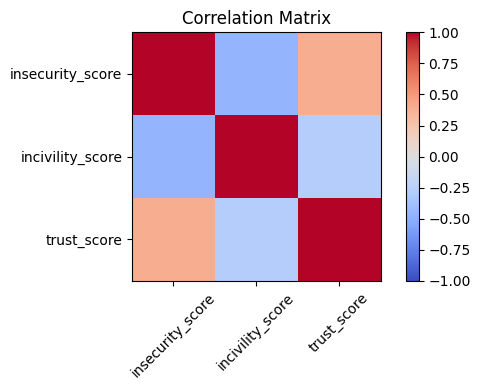

In [35]:
plt.figure(figsize=(6, 4))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Cluster segmentation

Clustering is used to identify perception profiles based on insecurity, incivility, and trust.

In [36]:
cluster_cols = ["insecurity_score", "incivility_score", "trust_score"]

df_cluster = df_model[cluster_cols].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

df_model.loc[df_cluster.index, "cluster"] = df_cluster["cluster"]
df_model["cluster"] = df_model["cluster"].astype("Int64")

In [37]:
cluster_summary = (
    df_cluster.groupby("cluster")[["insecurity_score", "incivility_score", "trust_score"]]
    .mean()
    .round(4)
)

cluster_summary

,insecurity_score,incivility_score,trust_score
cluster,,,
0,1.716397,1.571773,3.055531
1,1.642085,1.417481,1.979597
2,1.184895,1.87229,1.803571


In [38]:
cluster_by_gender = pd.crosstab(
    df_cluster["cluster"],
    df_model.loc[df_cluster.index, "SEXO"],
    normalize="columns"
).rename(columns={1: "Men", 2: "Women"}).round(4)

cluster_by_gender

SEXO,Men,Women
cluster,,
0,0.2193,0.2610
1,0.2818,0.3358
2,0.4989,0.4032


In [39]:
top10_cities = city_insecurity.head(10).index.tolist()

cluster_by_city_top10 = pd.crosstab(
    df_cluster["cluster"],
    df_model.loc[df_cluster.index, "NOM_CD"],
    normalize="columns"
)[top10_cities].round(4)

cluster_by_city_top10

NOM_CD,URUAPAN,CULIACAN ROSALES,FRESNILLO,TAPACHULA,CHILPANCINGO DE LOS BRAVO,VILLAHERMOSA,HEROICA PUEBLA DE ZARAGOZA,IRAPUATO,CUERNAVACA,ECATEPEC DE MORELOS
cluster,,,,,,,,,,
0,0.4168,0.3907,0.5948,0.3809,0.4411,0.3127,0.3193,0.4298,0.3038,0.2816
1,0.3835,0.3370,0.1697,0.3412,0.2820,0.4031,0.4371,0.3562,0.4572,0.5267
2,0.1998,0.2723,0.2356,0.2779,0.2769,0.2842,0.2436,0.2139,0.2389,0.1917


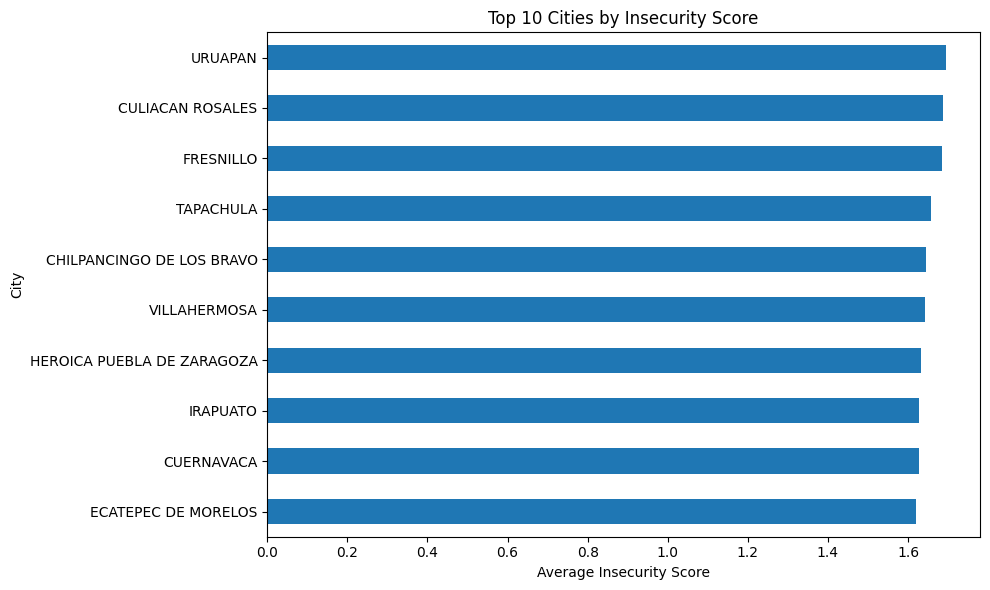

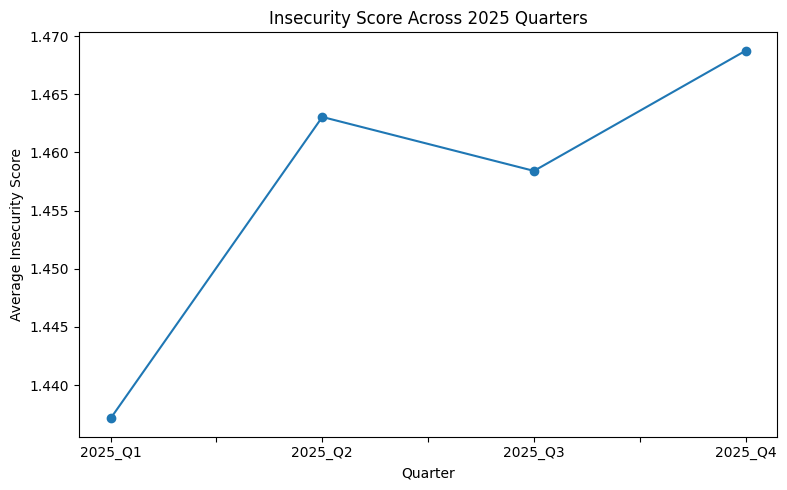

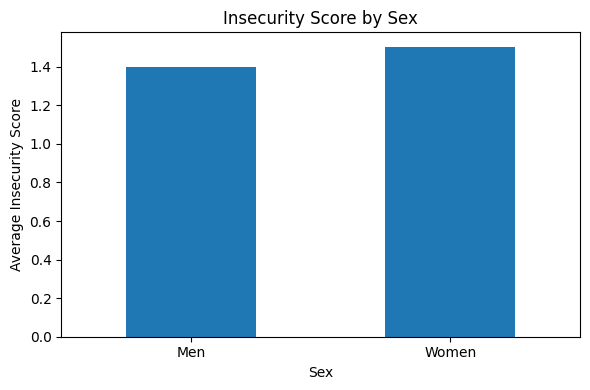

In [40]:
plot_top_cities(city_insecurity, top_n=10, output_path=FIGURES_DIR / "top_10_cities_insecurity.png")
plot_quarter_trend(quarter_trend, output_path=FIGURES_DIR / "quarter_trend_insecurity.png")
plot_sex_comparison(sex_insecurity, output_path=FIGURES_DIR / "sex_insecurity.png")

## Exporting final artifacts

In [41]:
kpi_table = pd.DataFrame({
    "metric": [
        "average_insecurity_score",
        "high_insecurity_share",
        "highest_quarter_score",
        "highest_insecurity_city",
        "women_insecurity_score",
        "men_insecurity_score",
    ],
    "value": [
        round(df_model["insecurity_score"].mean(), 4),
        round((df_model["insecurity_level"] == "High").mean(), 4),
        round(quarter_trend.max(), 4),
        city_insecurity.idxmax(),
        round(sex_insecurity["Women"], 4),
        round(sex_insecurity["Men"], 4),
    ]
})

kpi_table.to_csv(TABLES_DIR / "kpi_table.csv", index=False, encoding="utf-8")
quarter_trend.to_csv(TABLES_DIR / "quarter_trend.csv", encoding="utf-8")
city_insecurity.head(10).to_csv(TABLES_DIR / "city_insecurity_top10.csv", encoding="utf-8")
sex_insecurity.to_csv(TABLES_DIR / "gender_insecurity.csv", encoding="utf-8")
cluster_summary.to_csv(TABLES_DIR / "cluster_summary.csv", encoding="utf-8")
cluster_by_gender.to_csv(TABLES_DIR / "cluster_by_gender.csv", encoding="utf-8")
cluster_by_city_top10.to_csv(TABLES_DIR / "cluster_by_city_top10.csv", encoding="utf-8")

df_model.to_csv(PROCESSED_DIR / "ensu_2025_model_final.csv", index=False, encoding="utf-8")

print("All final artifacts exported.")

All final artifacts exported.


In [42]:
df_model_report = df_model[df_model["insecurity_level"] != "Unknown"].copy()

df_dashboard = df_model_report[[
    "NOM_CD",
    "quarter",
    "SEXO",
    "insecurity_score",
    "insecurity_level",
    "cluster"
]].copy()

df_dashboard.to_csv(PROCESSED_DIR / "dashboard_data_final.csv", index=False, encoding="utf-8")
print("Dashboard CSV exported.")

Dashboard CSV exported.


## Key findings

- Perceived insecurity is unevenly distributed, with the high category representing the largest group.
- A slight upward trend is observed across 2025, with the highest level in Q4.
- Women report higher perceived insecurity than men.
- Perceived insecurity is concentrated in specific cities rather than evenly distributed.
- Cluster analysis reveals that insecurity is experienced through differentiated profiles rather than a single general pattern.